# Factor Investing in 2026: From Fama-French to Neural Networks

**A practitioner's walkthrough of modern factor models, the risks nobody talks about enough, and why machines might finally be better at building factors than we are.**

*Author: Uchenna Ejike*

---

This notebook accompanies the Medium article of the same title. It implements the core techniques discussed in the article using real data from the Kenneth French Data Library, covering:

1. Fama-French factor returns and portfolio sorts
2. Fama-MacBeth two-pass regressions with GMM inference
3. Bayesianised p-values for factor validation
4. Factor competition and redundancy analysis
5. Machine learning for return prediction (comparing linear vs nonlinear)
6. Simulated NNAFC-style factor construction with neural networks

All code is self-contained and reproducible.

## 1. Setup and data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import chi2
from numpy.linalg import inv
from numpy import (
    cov, mean, hstack, multiply, sqrt, diag,
    squeeze, ones, array, vstack, kron, zeros, eye
)

# np.mat removed in numpy 2.x; use np.asmatrix instead
def mat(x):
    return np.asmatrix(x)
import warnings
warnings.filterwarnings("ignore")

# plotting style
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "figure.dpi": 150,
    "savefig.dpi": 200,
    "savefig.bbox": "tight",
})

COLORS = {
    "market": "#2C3E50",
    "smb": "#E67E22",
    "hml": "#27AE60",
    "rmw": "#8E44AD",
    "cma": "#C0392B",
    "rf": "#95A5A6",
    "accent": "#3498DB",
    "highlight": "#E74C3C",
}

print("Setup complete.")

Setup complete.


## 2. Loading Fama-French factor data

We pull the Fama-French 5-factor data and 25 size/value portfolio returns directly from Ken French's data library. These are monthly returns from July 1963 onwards.

In [2]:
import urllib.request
import zipfile
import io
import os

# --- Fama-French 5 Factors ---
ff5_url = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_5_Factors_2x3_CSV.zip"
urllib.request.urlretrieve(ff5_url, "/tmp/ff5.zip")

with zipfile.ZipFile("/tmp/ff5.zip", "r") as z:
    fname = z.namelist()[0]
    with z.open(fname) as f:
        lines = f.read().decode("utf-8").splitlines()

# find the header row
header_idx = None
for i, line in enumerate(lines):
    if "Mkt-RF" in line:
        header_idx = i
        break

# find the annual section break
end_idx = None
for i in range(header_idx + 1, len(lines)):
    line = lines[i].strip()
    if line == "" or not line[0].isdigit() and not line[0] == "-":
        end_idx = i
        break

csv_text = "\n".join(lines[header_idx:end_idx])
df_ff = pd.read_csv(io.StringIO(csv_text), skipinitialspace=True)
df_ff.columns = df_ff.columns.str.strip()
df_ff.rename(columns={df_ff.columns[0]: "date", "Mkt-RF": "MKT_RF"}, inplace=True)
df_ff["date"] = df_ff["date"].astype(str).str.strip()
df_ff = df_ff[df_ff["date"].str.len() == 6].copy()
df_ff["date"] = pd.to_datetime(df_ff["date"], format="%Y%m")
df_ff.set_index("date", inplace=True)

for col in df_ff.columns:
    df_ff[col] = pd.to_numeric(df_ff[col], errors="coerce") / 100.0

# trim to 1963-07 through latest
df_ff = df_ff.loc["1963-07":].copy()
df_ff.dropna(inplace=True)

print(f"Fama-French 5 factors: {df_ff.shape[0]} months, {df_ff.columns.tolist()}")
df_ff.head()

Fama-French 5 factors: 753 months, ['MKT_RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF']


,MKT_RF,SMB,HML,RMW,CMA,RF
date,,,,,,
1963-07-01,-0.0039,-0.0048,-0.0081,0.0064,-0.0115,0.0027
1963-08-01,0.0508,-0.0080,0.0170,0.0040,-0.0038,0.0025
1963-09-01,-0.0157,-0.0043,0.0000,-0.0078,0.0015,0.0027
1963-10-01,0.0254,-0.0134,-0.0004,0.0279,-0.0225,0.0029
1963-11-01,-0.0086,-0.0085,0.0173,-0.0043,0.0227,0.0027


## 3. Factor returns through time

The market factor is the most volatile because it is the only long-equity factor. The others (SMB, HML, RMW, CMA) are long-short portfolios and tend to hover closer to zero most of the time.

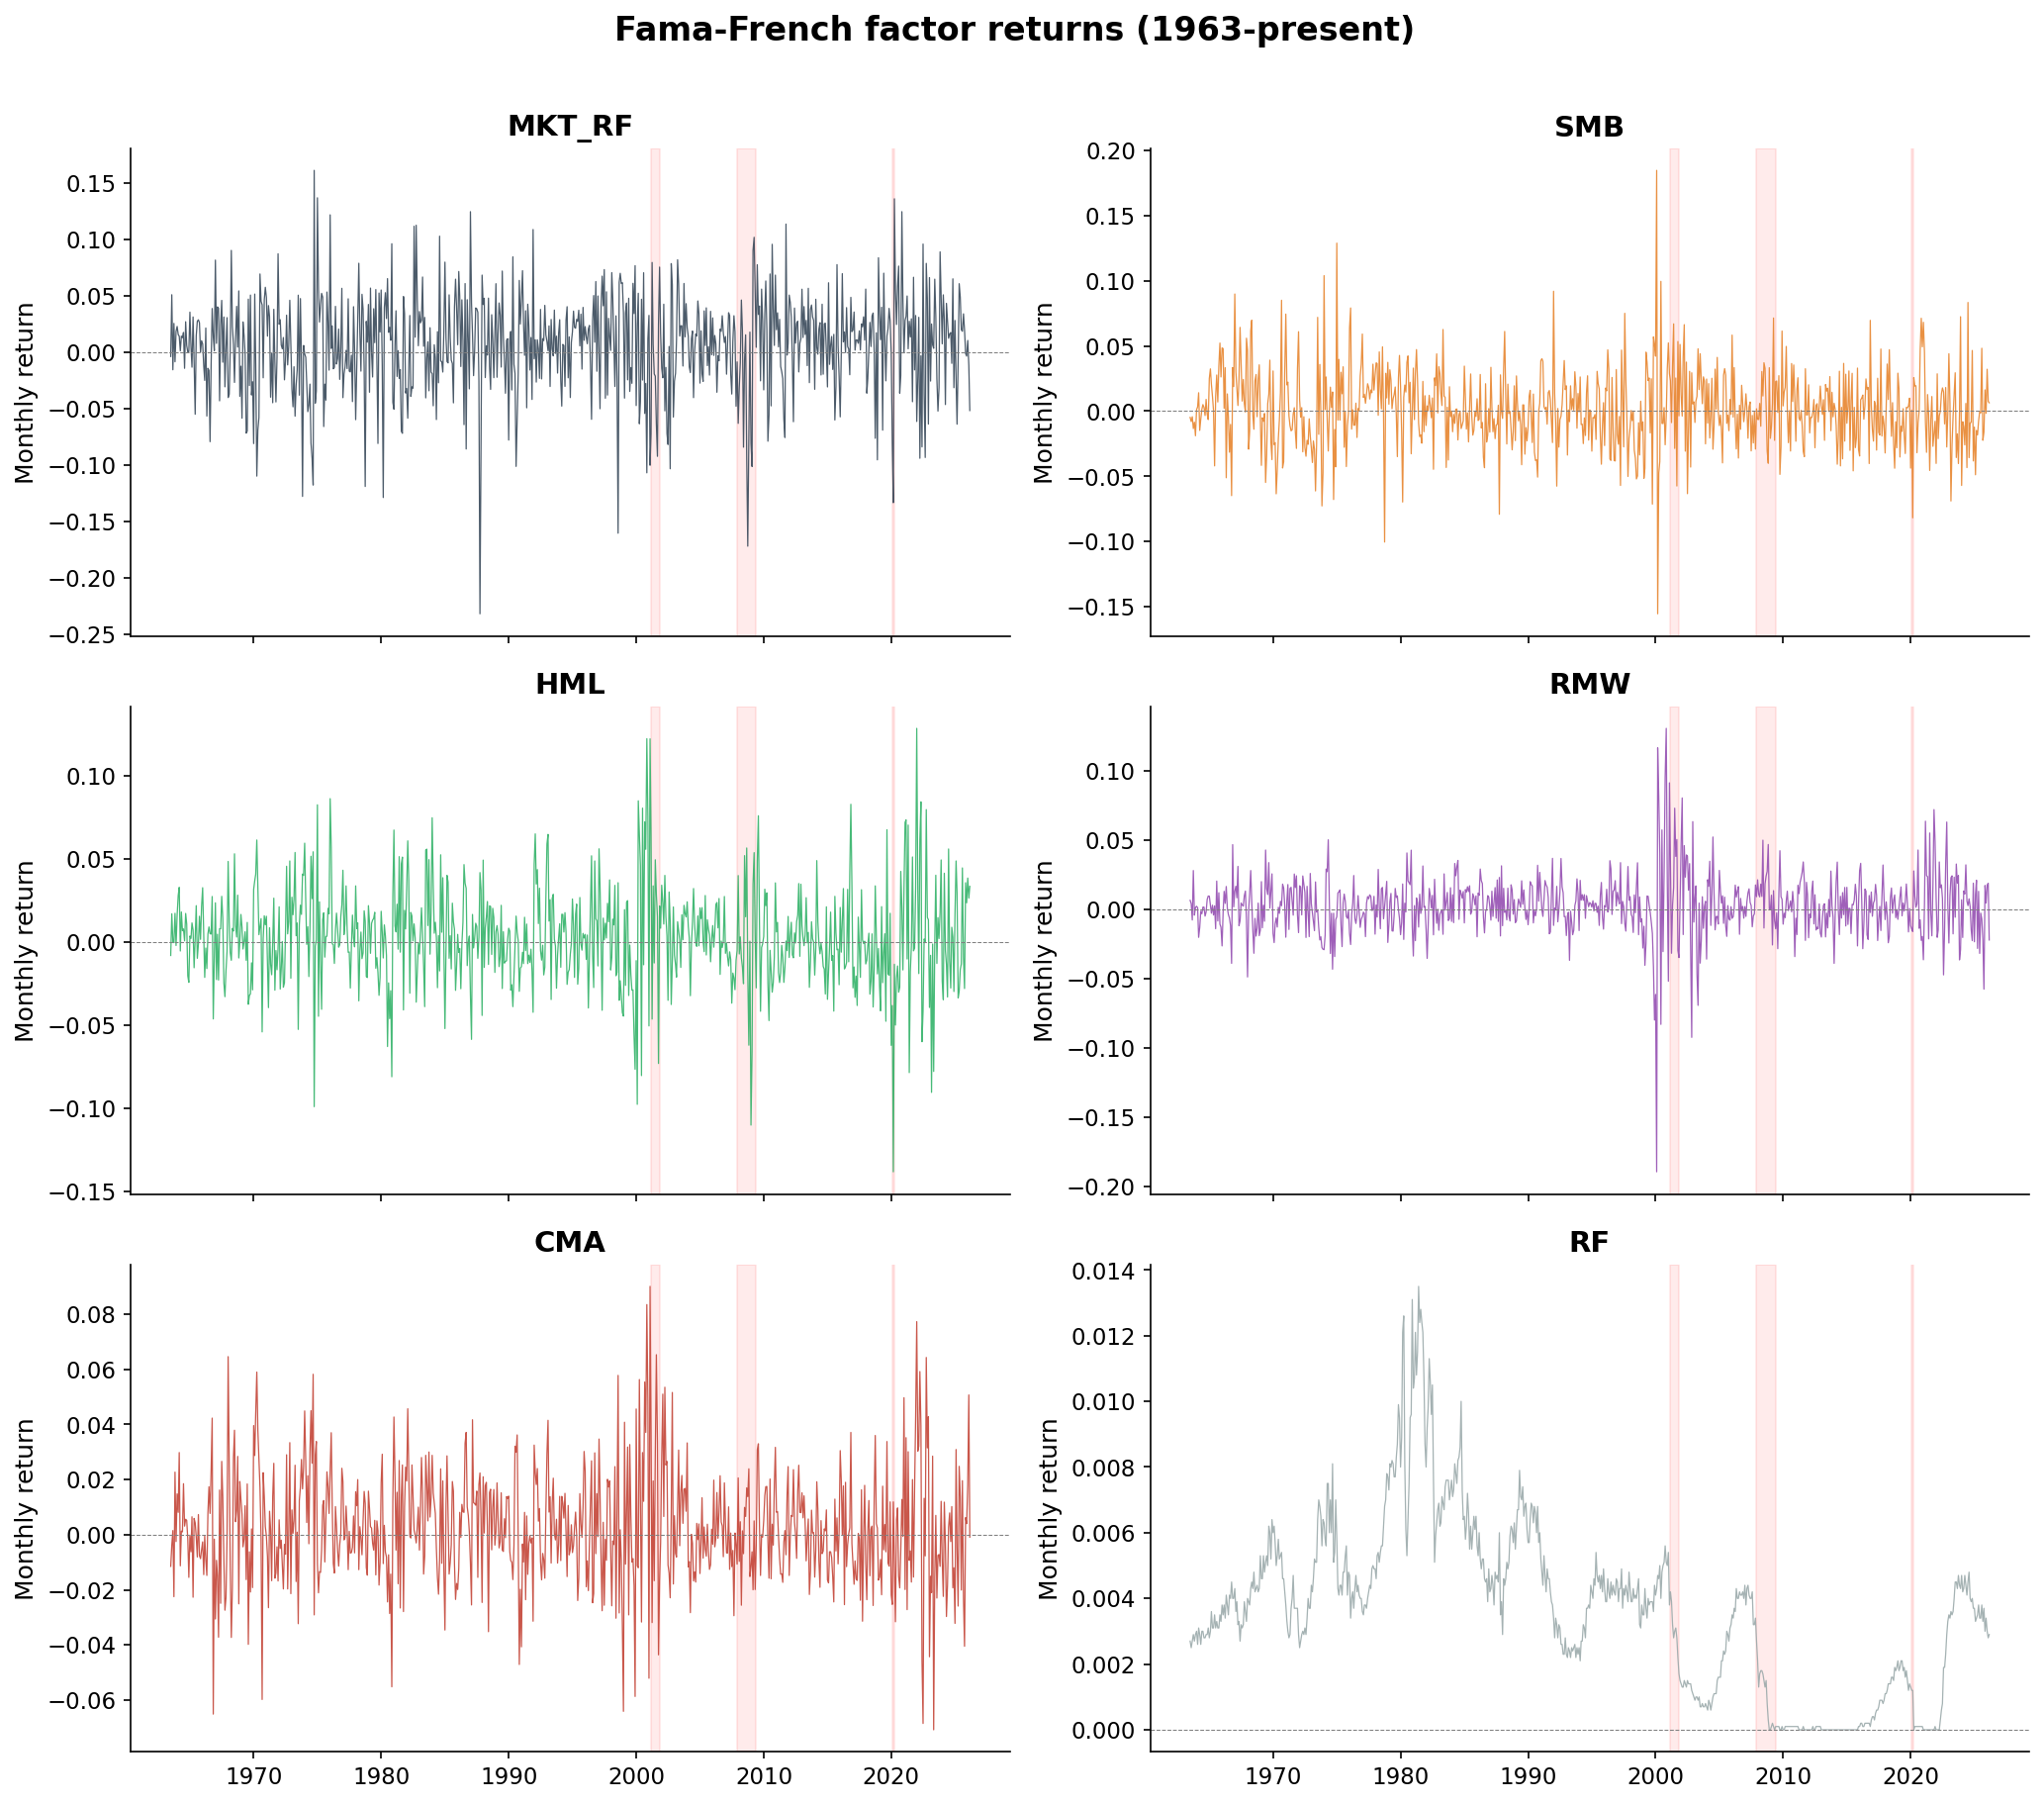

Saved: fig1_factor_returns_timeseries.png


In [3]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12), sharex=True)
factor_list = ["MKT_RF", "SMB", "HML", "RMW", "CMA", "RF"]
color_list = [
    COLORS["market"], COLORS["smb"], COLORS["hml"],
    COLORS["rmw"], COLORS["cma"], COLORS["rf"]
]

for ax, factor, color in zip(axes.flat, factor_list, color_list):
    ax.plot(df_ff.index, df_ff[factor], color=color, linewidth=0.6, alpha=0.85)
    ax.axhline(0, color="grey", linewidth=0.5, linestyle="--")
    ax.set_title(factor, fontweight="bold")
    ax.set_ylabel("Monthly return")
    # shade recessions roughly
    for start, end in [("2001-03", "2001-11"), ("2007-12", "2009-06"), ("2020-02", "2020-04")]:
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.08, color="red")

fig.suptitle("Fama-French factor returns (1963-present)", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("fig1_factor_returns_timeseries.png")
plt.show()
print("Saved: fig1_factor_returns_timeseries.png")

## 4. Cumulative wealth from factor portfolios

A dollar invested in each factor portfolio in July 1963, compounded monthly. This makes the long-run premia (and their volatility) tangible.

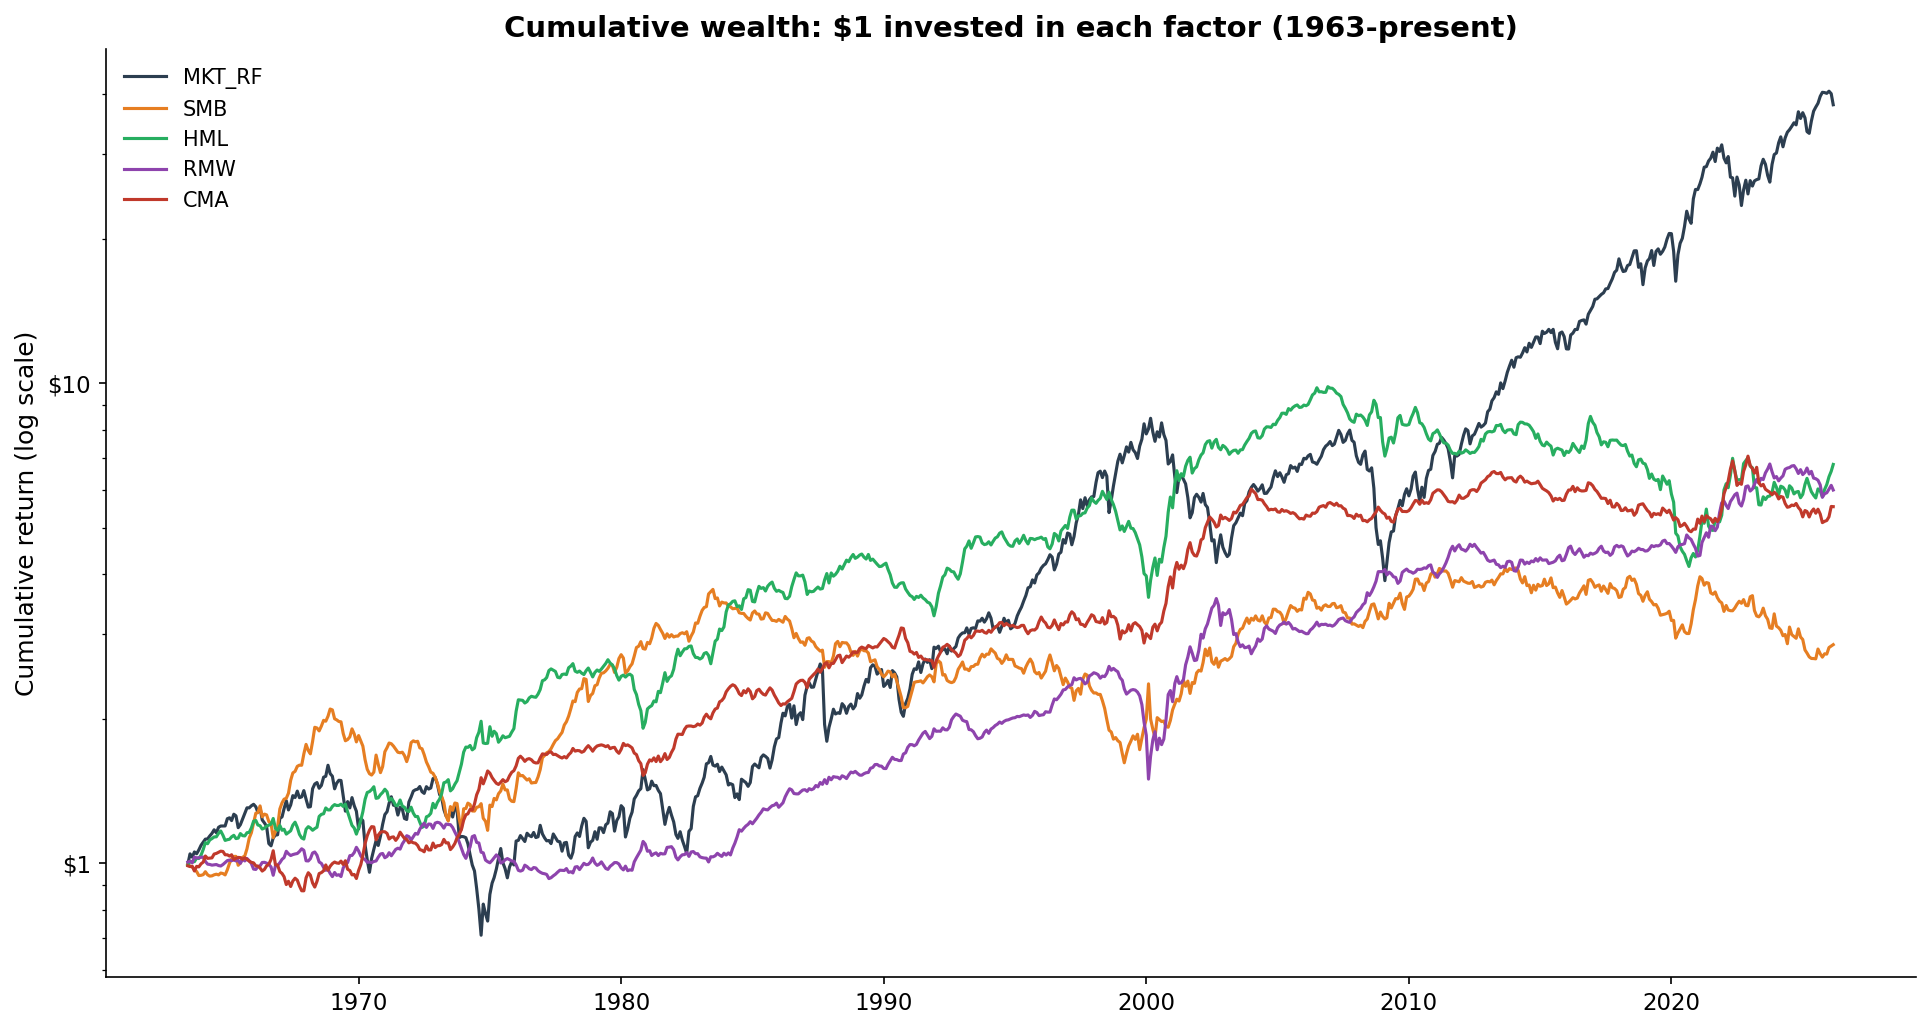

Saved: fig2_cumulative_wealth.png


In [4]:
factors_to_plot = ["MKT_RF", "SMB", "HML", "RMW", "CMA"]
cumulative = (1 + df_ff[factors_to_plot]).cumprod()

fig, ax = plt.subplots(figsize=(13, 7))
for factor, color in zip(factors_to_plot, color_list[:5]):
    ax.plot(cumulative.index, cumulative[factor], label=factor, color=color, linewidth=1.5)

ax.set_yscale("log")
ax.set_ylabel("Cumulative return (log scale)")
ax.set_xlabel("")
ax.set_title("Cumulative wealth: $1 invested in each factor (1963-present)", fontweight="bold")
ax.legend(frameon=False, loc="upper left")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()
plt.savefig("fig2_cumulative_wealth.png")
plt.show()
print("Saved: fig2_cumulative_wealth.png")

## 5. Average annual factor returns by decade

Factor premia are not constant. The size premium (SMB) was strong in the 1970s-80s but has weakened. The value premium (HML) had a terrible stretch in the 2010s. This time-varying nature is one reason factor timing is so tempting and so difficult.

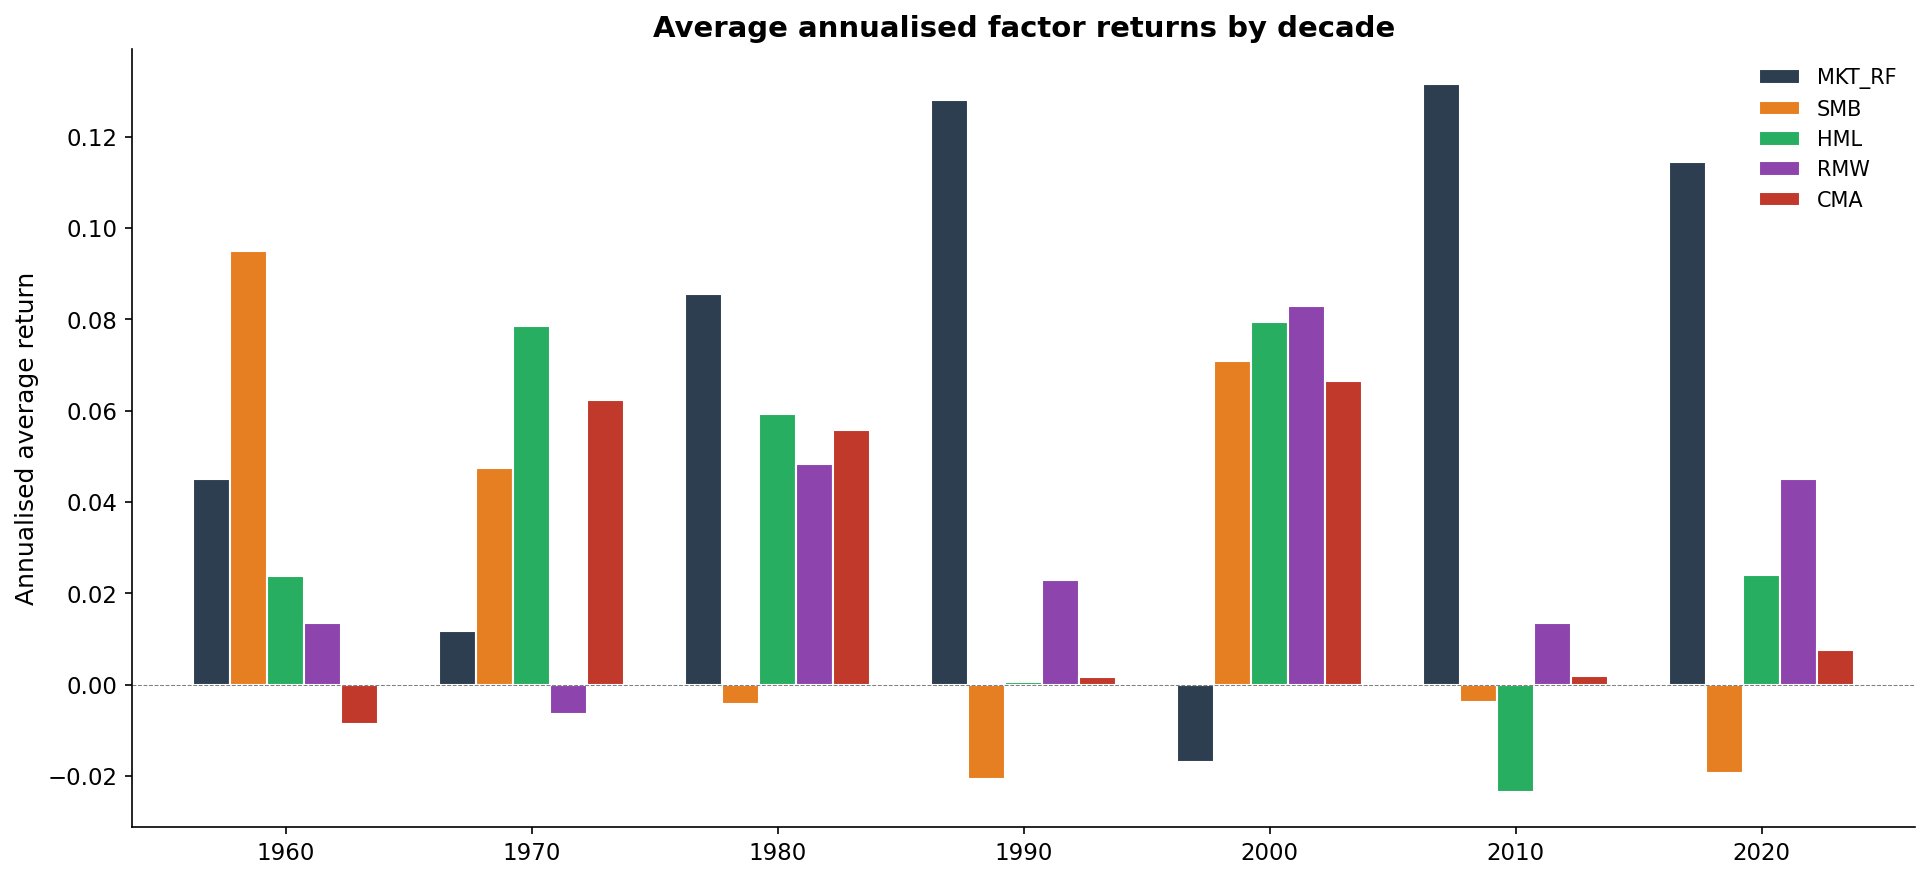

Saved: fig3_factor_returns_by_decade.png


In [5]:
df_ff_yr = df_ff[factors_to_plot].copy()
df_ff_yr["decade"] = (df_ff_yr.index.year // 10) * 10
decade_means = df_ff_yr.groupby("decade")[factors_to_plot].mean() * 12  # annualise

fig, ax = plt.subplots(figsize=(13, 6))
decade_means.plot(kind="bar", ax=ax, color=color_list[:5], edgecolor="white", width=0.75)
ax.set_ylabel("Annualised average return")
ax.set_xlabel("")
ax.set_title("Average annualised factor returns by decade", fontweight="bold")
ax.axhline(0, color="grey", linewidth=0.5, linestyle="--")
ax.legend(frameon=False)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.savefig("fig3_factor_returns_by_decade.png")
plt.show()
print("Saved: fig3_factor_returns_by_decade.png")

## 6. Factor correlation matrix

Understanding correlations between factors matters for portfolio construction and for detecting redundancy. HML's high correlation with CMA is one reason Fama and French (2015) found HML redundant in their 5-factor model.

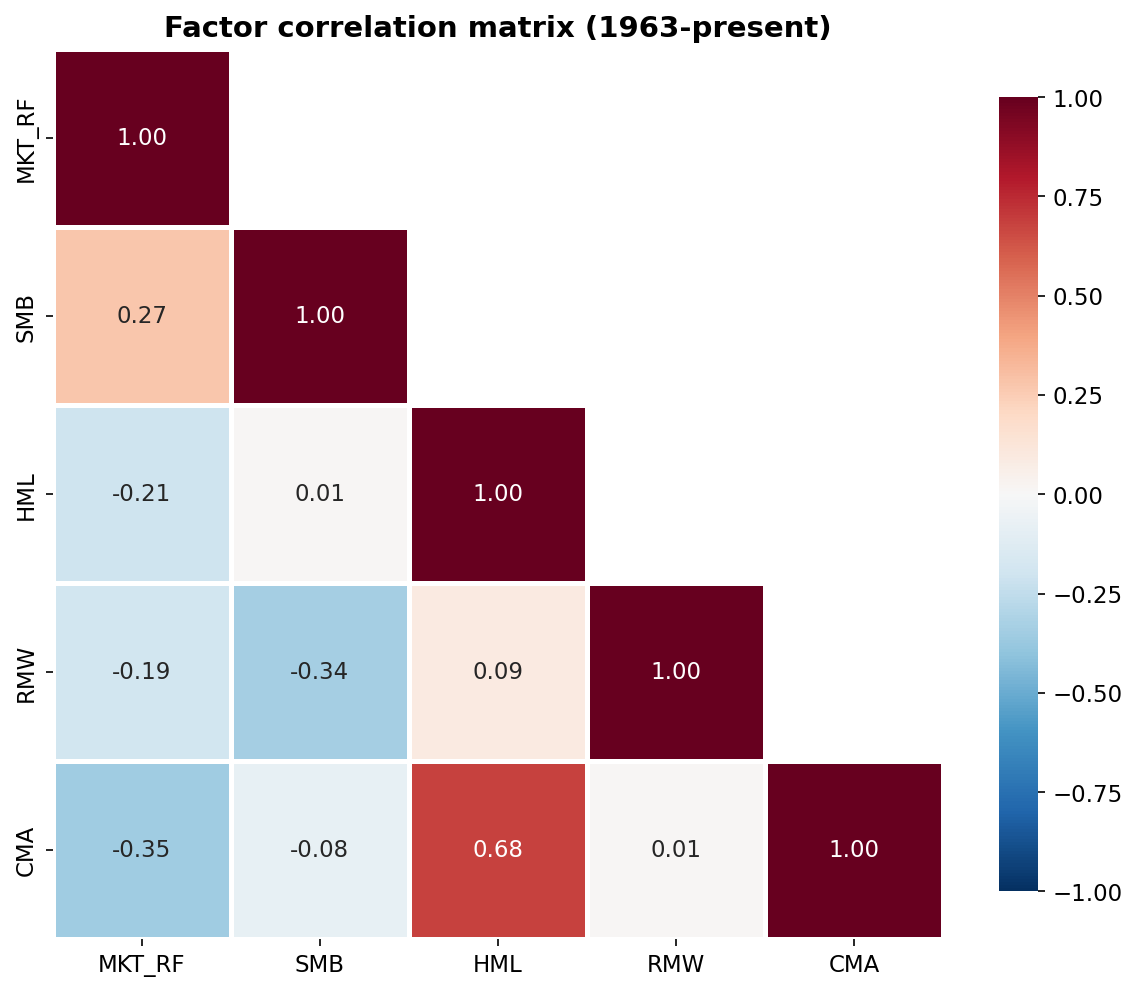

Saved: fig4_factor_correlation.png


In [6]:
corr = df_ff[factors_to_plot].corr()

fig, ax = plt.subplots(figsize=(8, 7))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
    mask=mask, square=True, linewidths=1.5, ax=ax,
    vmin=-1, vmax=1, cbar_kws={"shrink": 0.8}
)
ax.set_title("Factor correlation matrix (1963-present)", fontweight="bold")
plt.tight_layout()
plt.savefig("fig4_factor_correlation.png")
plt.show()
print("Saved: fig4_factor_correlation.png")

## 7. Factor competition: is HML redundant?

Following Fama and French (2015), we regress each factor on all the others. If the intercept (alpha) is not significantly different from zero, that factor is redundant given the rest. We reproduce their finding that HML's alpha is insignificant.

In [7]:
factor_names = ["MKT_RF", "SMB", "HML", "RMW", "CMA"]
competition_results = []

for target in factor_names:
    others = [f for f in factor_names if f != target]
    Y = df_ff[target]
    X = sm.add_constant(df_ff[others])
    result = sm.OLS(Y, X).fit()
    
    alpha = result.params["const"]
    alpha_t = result.tvalues["const"]
    alpha_p = result.pvalues["const"]
    r2 = result.rsquared
    
    if alpha_p < 0.001:
        sig = "***"
    elif alpha_p < 0.01:
        sig = "**"
    elif alpha_p < 0.05:
        sig = "*"
    else:
        sig = ""
    
    competition_results.append({
        "Factor": target,
        "Alpha (monthly)": f"{alpha:.5f}",
        "t-stat": f"{alpha_t:.3f}",
        "p-value": f"{alpha_p:.4f}",
        "Sig": sig,
        "R-squared": f"{r2:.3f}"
    })

df_comp = pd.DataFrame(competition_results)
print("Factor competition: alpha of each factor regressed on all others")
print("=" * 72)
print(df_comp.to_string(index=False))
print()
print("As Fama and French (2015) found, HML's alpha is not significant")
print("when the other four factors are present.")

Factor competition: alpha of each factor regressed on all others
Factor Alpha (monthly) t-stat p-value Sig R-squared
MKT_RF         0.00768  5.161  0.0000 ***     0.198
   SMB         0.00207  1.990  0.0470   *     0.176
   HML        -0.00028 -0.348  0.7280         0.482
   RMW         0.00352  4.599  0.0000 ***     0.151
   CMA         0.00211  3.932  0.0001 ***     0.522

As Fama and French (2015) found, HML's alpha is not significant
when the other four factors are present.


## 8. Fama-MacBeth regressions

This is the two-pass procedure from Fama and MacBeth (1973). We use the 25 Fama-French size/value portfolios. The implementation follows Sheppard (2023), including full GMM-based inference for proper standard errors and the J-test for model specification.

In [8]:
# --- Load 25 portfolios ---
port_url = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/25_Portfolios_5x5_CSV.zip"
urllib.request.urlretrieve(port_url, "/tmp/port25.zip")

with zipfile.ZipFile("/tmp/port25.zip", "r") as z:
    fname = z.namelist()[0]
    with z.open(fname) as f:
        lines = f.read().decode("utf-8").splitlines()

# find header
header_idx = None
for i, line in enumerate(lines):
    if "SMALL" in line.upper() or "Lo" in line:
        header_idx = i
        break

# find end of monthly data
end_idx = None
for i in range(header_idx + 1, len(lines)):
    line = lines[i].strip()
    if line == "" or (not line[0].isdigit() and line[0] != "-"):
        end_idx = i
        break

csv_text = "\n".join(lines[header_idx:end_idx])
df_port = pd.read_csv(io.StringIO(csv_text), skipinitialspace=True)
df_port.columns = df_port.columns.str.strip()
df_port.rename(columns={df_port.columns[0]: "date"}, inplace=True)
df_port["date"] = df_port["date"].astype(str).str.strip()
df_port = df_port[df_port["date"].str.len() == 6].copy()
df_port["date"] = pd.to_datetime(df_port["date"], format="%Y%m")
df_port.set_index("date", inplace=True)

for col in df_port.columns:
    df_port[col] = pd.to_numeric(df_port[col], errors="coerce") / 100.0

# align dates
common_idx = df_ff.index.intersection(df_port.index)
df_ff_aligned = df_ff.loc[common_idx]
df_port_aligned = df_port.loc[common_idx]

print(f"25 portfolios: {df_port_aligned.shape[0]} months x {df_port_aligned.shape[1]} portfolios")
print(f"Factors aligned: {df_ff_aligned.shape[0]} months")

25 portfolios: 753 months x 25 portfolios
Factors aligned: 753 months


In [9]:
# Fama-MacBeth implementation (following Sheppard 2023)
factors = mat(df_ff_aligned[["MKT_RF", "SMB", "HML"]].values)
riskfree = mat(df_ff_aligned["RF"].values).T
portfolios = mat(df_port_aligned.values)

T, K = factors.shape
T, N = portfolios.shape
excessReturns = portfolios - riskfree

# Step 1: Time-series regressions (estimate betas)
X = sm.add_constant(factors)
ts_res = sm.OLS(np.asarray(excessReturns), np.asarray(X)).fit()
alpha = ts_res.params[0]
beta = ts_res.params[1:]
avgExcessReturns = mean(excessReturns, 0)

# Step 2: Cross-sectional regression (estimate risk premia)
cs_res = sm.OLS(np.asarray(avgExcessReturns).T, np.asarray(beta).T).fit()
riskPremia = cs_res.params

# GMM-based inference
X = sm.add_constant(factors)
p = vstack((alpha, beta))
epsilon = excessReturns - X @ p
moments1 = kron(epsilon, ones((1, K + 1)))
moments1 = multiply(moments1, kron(ones((1, N)), X))
u = excessReturns - riskPremia[None, :] @ beta
moments2 = u * beta.T

S = mat(cov(hstack((moments1, moments2)).T))

G = mat(zeros((N * K + N + K, N * K + N + K)))
SigmaX = (X.T @ X) / T
G[:N * K + N, :N * K + N] = kron(eye(N), SigmaX)
G[N * K + N:, N * K + N:] = -beta @ beta.T
for i in range(N):
    temp = zeros((K, K + 1))
    values = mean(u[:, i]) - multiply(beta[:, i], riskPremia)
    temp[:, 1:] = diag(values)
    G[N * K + N:, i * (K + 1):(i + 1) * (K + 1)] = temp

vcv = inv(G.T) * S * inv(G) / T

# J-test
vcvAlpha = vcv[0:N * K + N:4, 0:N * K + N:4]
J = alpha @ inv(vcvAlpha) @ alpha.T
J = J[0, 0]
Jpval = 1 - chi2(25).cdf(J)

# Risk premia results
vcvRiskPremia = vcv[N * K + N:, N * K + N:]
annualizedRP = 12 * riskPremia
arp = list(squeeze(annualizedRP))
arpSE = list(sqrt(12 * diag(vcvRiskPremia)))

print("Fama-MacBeth regression results (3-factor model)")
print("=" * 50)
print(f"{'':>15} {'Market':>10} {'SMB':>10} {'HML':>10}")
print(f"{'Premia (ann.)':>15} {arp[0]:>10.4f} {arp[1]:>10.4f} {arp[2]:>10.4f}")
print(f"{'Std. Error':>15} {arpSE[0]:>10.4f} {arpSE[1]:>10.4f} {arpSE[2]:>10.4f}")
print(f"{'t-stat':>15} {arp[0]/arpSE[0]:>10.4f} {arp[1]/arpSE[1]:>10.4f} {arp[2]/arpSE[2]:>10.4f}")
print()
print(f"J-test statistic: {J:.4f}")
print(f"J-test p-value:   {Jpval:.6f}")
print()
print("The J-test rejects the model, consistent with Sheppard (2023).")

Fama-MacBeth regression results (3-factor model)
                    Market        SMB        HML
  Premia (ann.)     0.0647     0.0246     0.0432
     Std. Error     0.0057     0.0040     0.0038
         t-stat    11.3391     6.2097    11.2222

J-test statistic: 95.9083
J-test p-value:   0.000000

The J-test rejects the model, consistent with Sheppard (2023).


## 9. Pricing errors: predicted vs realised returns

If the 3-factor model perfectly explained the cross-section, all 25 portfolios would lie on the 45-degree line. The scatter away from this line shows the model's mispricing, which the J-test formally rejects.

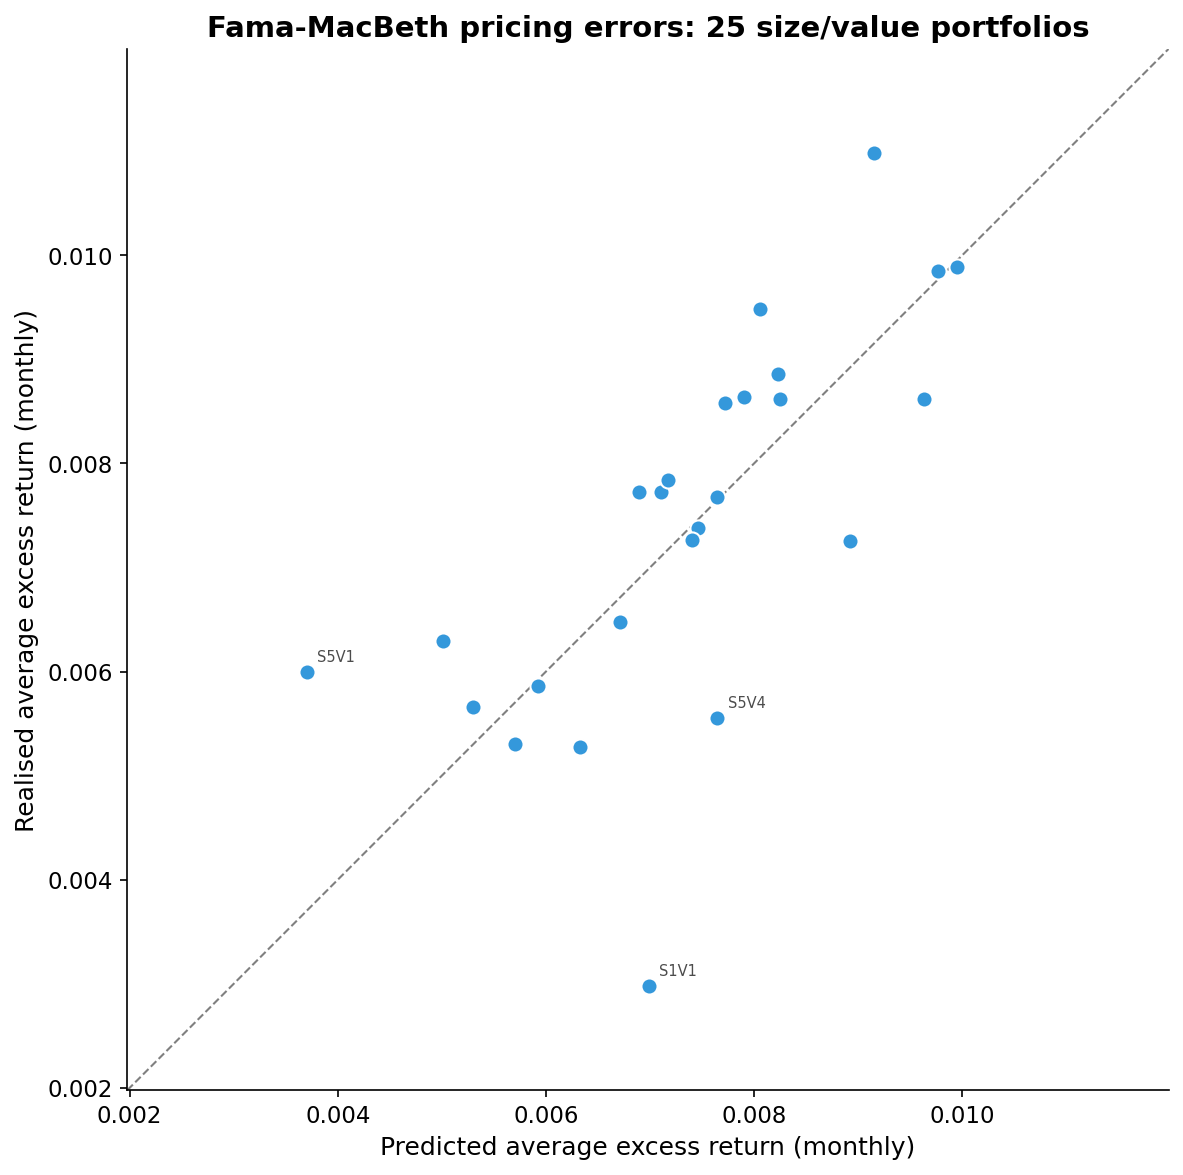

Saved: fig5_pricing_errors.png


In [10]:
predicted = np.asarray(beta.T @ np.asarray(riskPremia).reshape(-1, 1)).flatten()
realised = np.asarray(avgExcessReturns).flatten()

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(predicted, realised, s=60, color=COLORS["accent"], edgecolor="white", zorder=3)

# 45 degree line
lims = [min(predicted.min(), realised.min()) - 0.001, max(predicted.max(), realised.max()) + 0.001]
ax.plot(lims, lims, "--", color="grey", linewidth=1, zorder=1)

# label a few extreme points
for i in range(N):
    size_q = i // 5 + 1
    val_q = i % 5 + 1
    if abs(realised[i] - predicted[i]) > 0.002:
        ax.annotate(
            f"S{size_q}V{val_q}", (predicted[i], realised[i]),
            fontsize=7, alpha=0.7, textcoords="offset points", xytext=(5, 5)
        )

ax.set_xlabel("Predicted average excess return (monthly)")
ax.set_ylabel("Realised average excess return (monthly)")
ax.set_title("Fama-MacBeth pricing errors: 25 size/value portfolios", fontweight="bold")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig("fig5_pricing_errors.png")
plt.show()
print("Saved: fig5_pricing_errors.png")

## 10. Bayesianised p-values

Harvey (2017) proposed Bayesianised p-values to address the misinterpretation of standard p-values. The formula blends the t-statistic with a user-specified prior on the odds that the null is true:

**Bpv = exp(-t^2/2) * prior / (1 + exp(-t^2/2) * prior)**

We plot how the Bayesianised p-value varies with t-statistics for different prior beliefs.

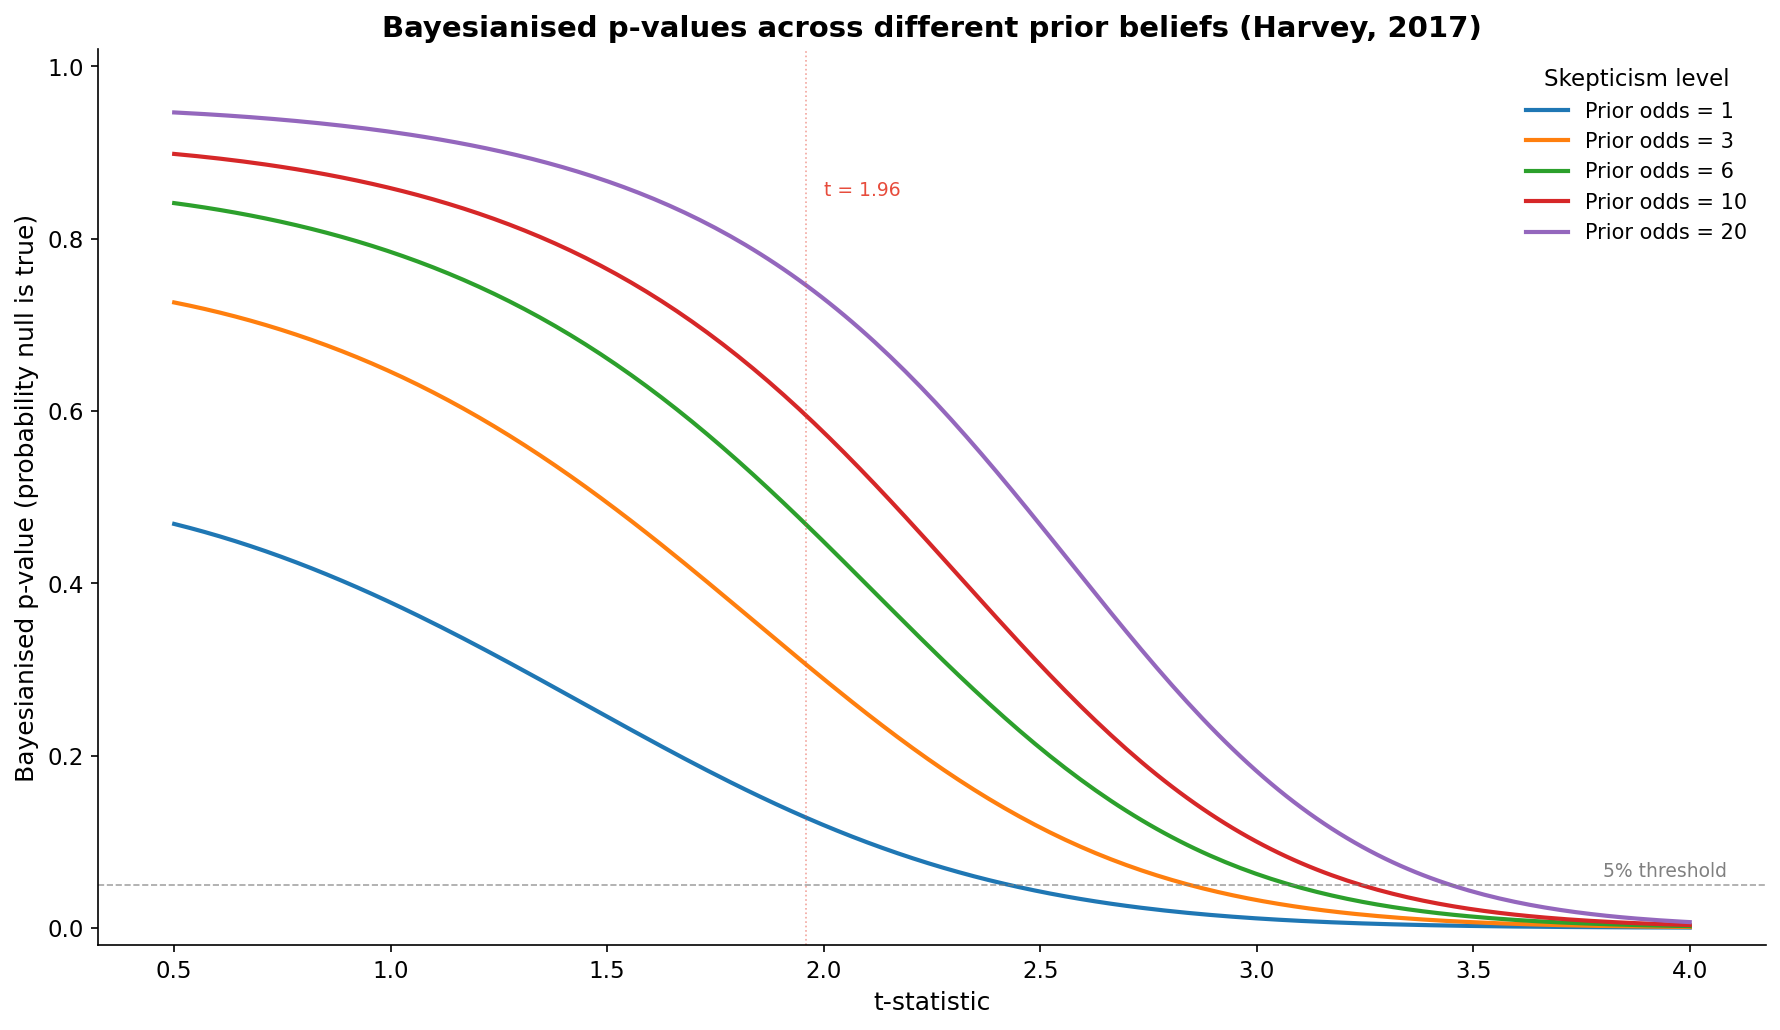

Saved: fig6_bayesianised_pvalues.png

With prior odds of 6 and t = 2.0:
  Bpv = 0.448 (44.8% chance the null is true)
  Compare to naive p-value interpretation of ~5%


In [11]:
t_values = np.linspace(0.5, 4.0, 200)
priors = [1, 3, 6, 10, 20]

fig, ax = plt.subplots(figsize=(12, 7))

for prior in priors:
    bpv = np.exp(-t_values**2 / 2) * prior / (1 + np.exp(-t_values**2 / 2) * prior)
    ax.plot(t_values, bpv, linewidth=2, label=f"Prior odds = {prior}")

ax.axhline(0.05, color="grey", linestyle="--", linewidth=0.8, alpha=0.7)
ax.annotate("5% threshold", xy=(3.8, 0.06), fontsize=9, color="grey")

ax.axvline(1.96, color=COLORS["highlight"], linestyle=":", linewidth=0.8, alpha=0.5)
ax.annotate("t = 1.96", xy=(2.0, 0.85), fontsize=9, color=COLORS["highlight"])

ax.set_xlabel("t-statistic")
ax.set_ylabel("Bayesianised p-value (probability null is true)")
ax.set_title("Bayesianised p-values across different prior beliefs (Harvey, 2017)", fontweight="bold")
ax.legend(frameon=False, title="Skepticism level")
ax.set_ylim(-0.02, 1.02)
plt.tight_layout()
plt.savefig("fig6_bayesianised_pvalues.png")
plt.show()
print("Saved: fig6_bayesianised_pvalues.png")
print()
print("With prior odds of 6 and t = 2.0:")
t_example = 2.0
prior_example = 6
bpv_example = np.exp(-t_example**2 / 2) * prior_example / (1 + np.exp(-t_example**2 / 2) * prior_example)
print(f"  Bpv = {bpv_example:.3f} (44.8% chance the null is true)")
print(f"  Compare to naive p-value interpretation of ~5%")

## 11. The August 2007 quant meltdown

Khandani and Lo (2007) showed that factor strategies suffered dramatically in August 2007 as leveraged funds unwound correlated positions simultaneously. We zoom into the market factor and HML around this period.

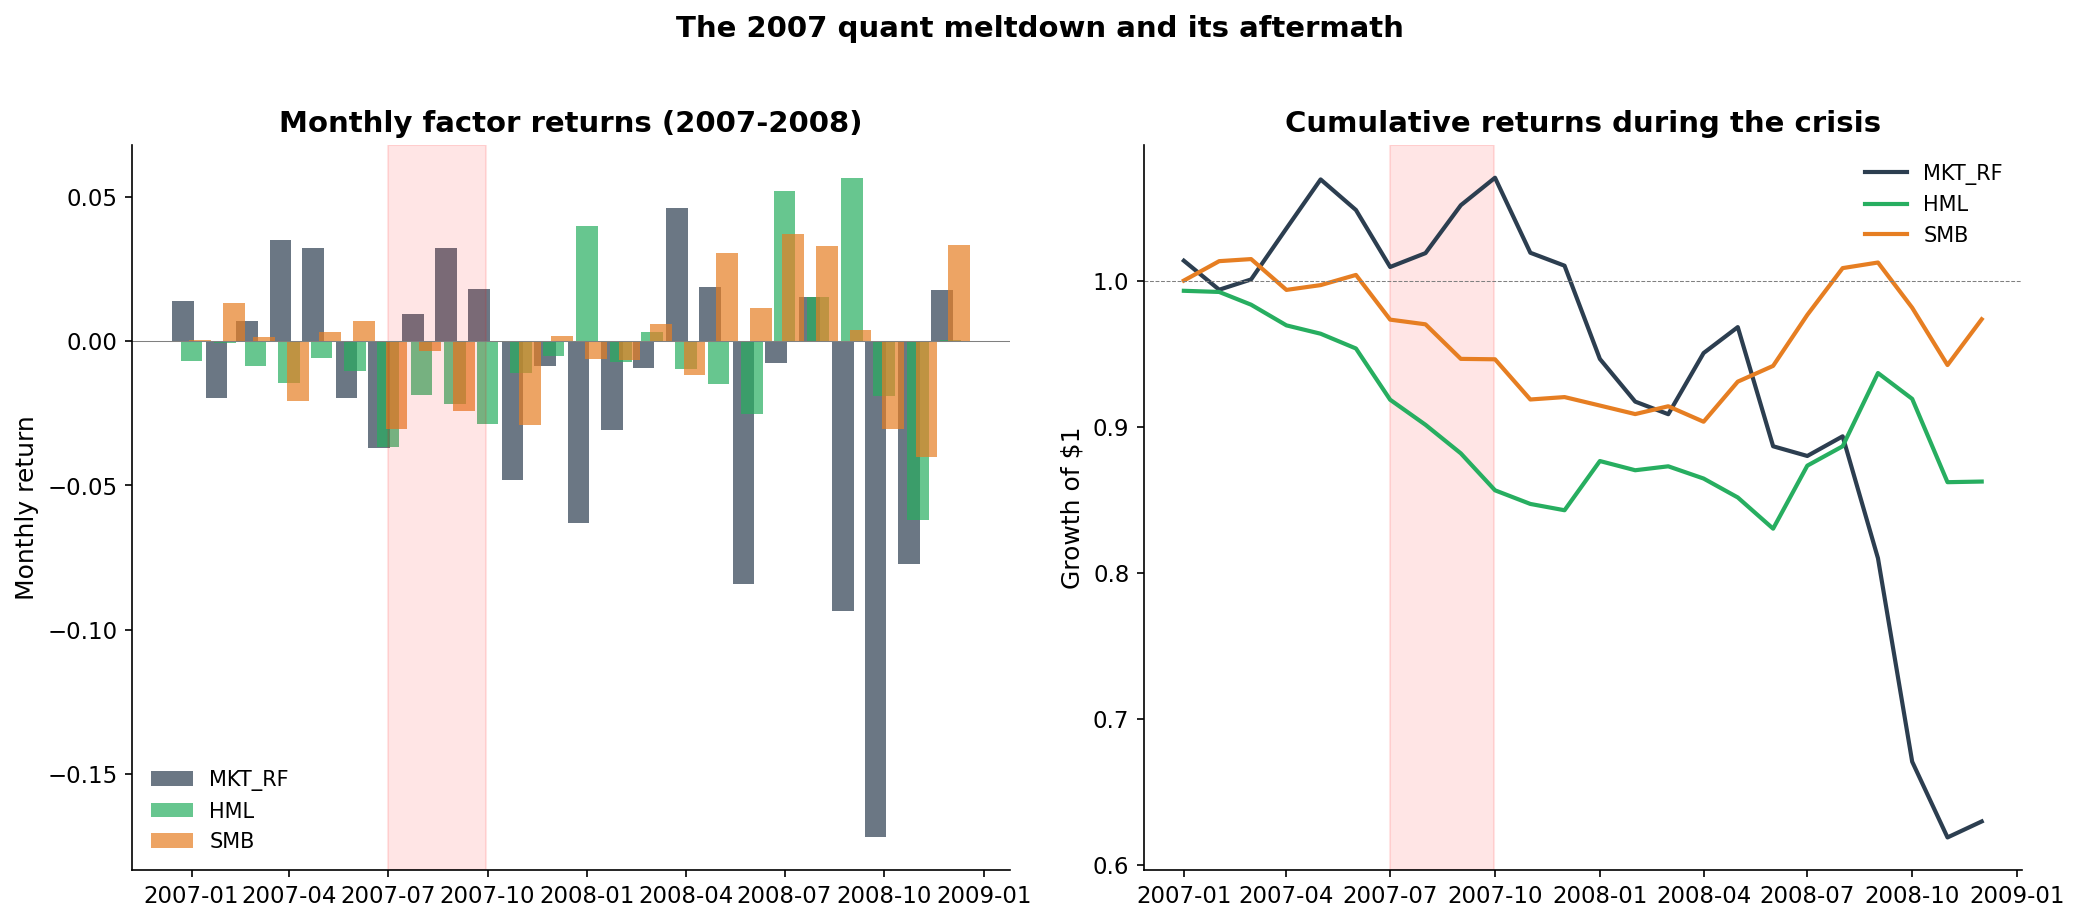

Saved: fig7_quant_meltdown_2007.png


In [12]:
crisis_window = df_ff.loc["2007-01":"2008-12", ["MKT_RF", "HML", "SMB"]].copy()
crisis_cum = (1 + crisis_window).cumprod()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Panel A: daily-proxy monthly returns
for factor, color in [("MKT_RF", COLORS["market"]), ("HML", COLORS["hml"]), ("SMB", COLORS["smb"])]:
    ax1.bar(
        crisis_window.index + pd.DateOffset(days={"MKT_RF": -8, "HML": 0, "SMB": 8}[factor]),
        crisis_window[factor],
        width=20, color=color, alpha=0.7, label=factor
    )

ax1.axhline(0, color="grey", linewidth=0.5)
ax1.axvspan(pd.Timestamp("2007-07-01"), pd.Timestamp("2007-09-30"), alpha=0.1, color="red")
ax1.set_title("Monthly factor returns (2007-2008)", fontweight="bold")
ax1.set_ylabel("Monthly return")
ax1.legend(frameon=False)

# Panel B: cumulative
for factor, color in [("MKT_RF", COLORS["market"]), ("HML", COLORS["hml"]), ("SMB", COLORS["smb"])]:
    ax2.plot(crisis_cum.index, crisis_cum[factor], color=color, linewidth=2, label=factor)

ax2.axvspan(pd.Timestamp("2007-07-01"), pd.Timestamp("2007-09-30"), alpha=0.1, color="red")
ax2.axhline(1, color="grey", linewidth=0.5, linestyle="--")
ax2.set_title("Cumulative returns during the crisis", fontweight="bold")
ax2.set_ylabel("Growth of $1")
ax2.legend(frameon=False)

fig.suptitle("The 2007 quant meltdown and its aftermath", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("fig7_quant_meltdown_2007.png")
plt.show()
print("Saved: fig7_quant_meltdown_2007.png")

## 12. Factor momentum: autocorrelation in factor returns

Gupta and Kelly (2019) and Ehsani and Linnainmaa (2019) documented significant autocorrelation in factor returns. If factors exhibit momentum, there may be profitable timing strategies (though Asness et al. 2017 are skeptical). We plot autocorrelation functions for the main factors.

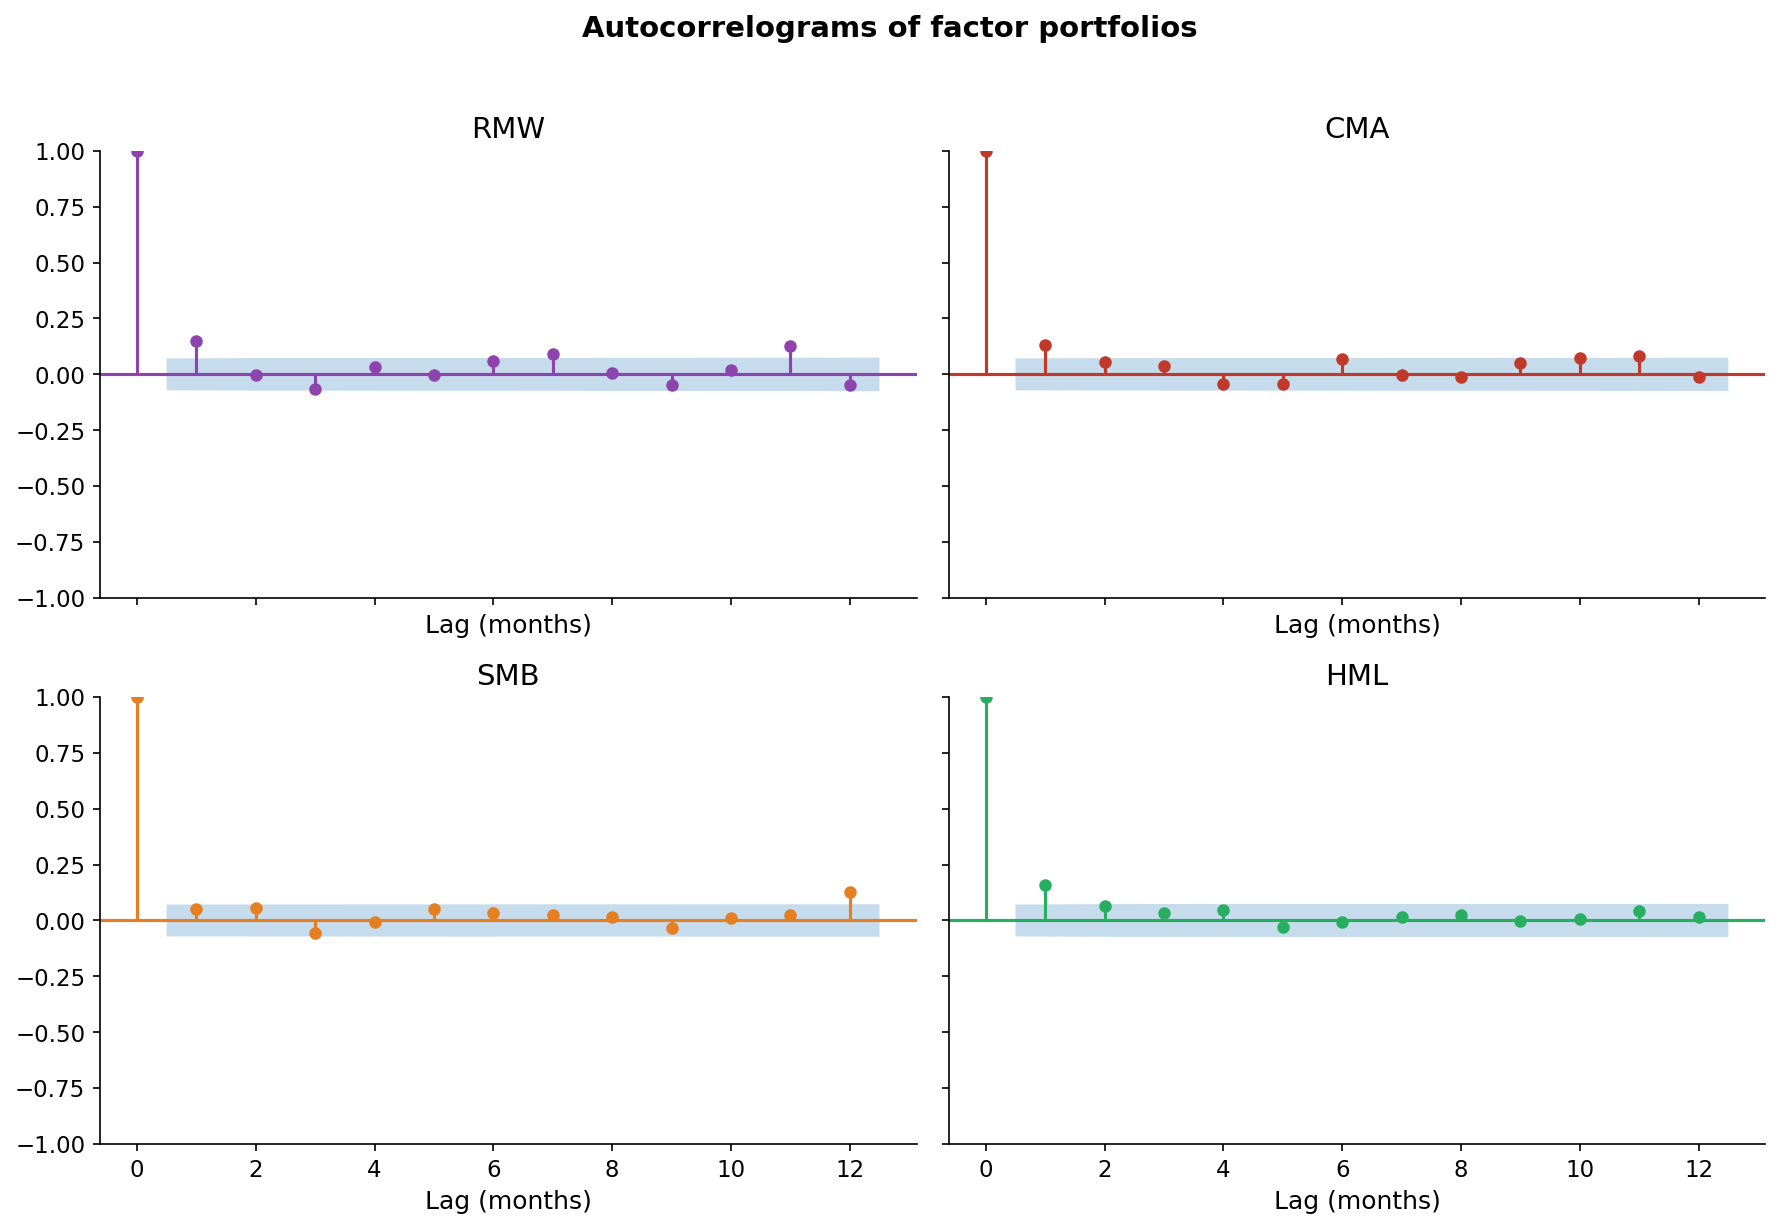

Saved: fig8_factor_autocorrelation.png


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
factor_acf = ["RMW", "CMA", "SMB", "HML"]
acf_colors = [COLORS["rmw"], COLORS["cma"], COLORS["smb"], COLORS["hml"]]

for ax, factor, color in zip(axes.flat, factor_acf, acf_colors):
    sm.graphics.tsa.plot_acf(
        df_ff[factor].dropna(), lags=12, ax=ax,
        title=factor, color=color, vlines_kwargs={"color": color}
    )
    ax.set_xlabel("Lag (months)")

fig.suptitle("Autocorrelograms of factor portfolios", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("fig8_factor_autocorrelation.png")
plt.show()
print("Saved: fig8_factor_autocorrelation.png")

## 13. Linear vs nonlinear models: a simulation

Gu, Kelly, and Xiu (2020) found that trees and neural networks outperform linear methods when predictor interactions matter. We simulate a cross-section with nonlinear interactions to illustrate this. This is a pedagogical demonstration, not a replication of their full study.

In [14]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.decomposition import PCA
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score
np.random.seed(42)

# simulate a panel: 500 stocks x 120 months, 20 characteristics
n_stocks = 500
n_months = 120
n_chars = 20

# generate characteristics
chars = np.random.randn(n_months * n_stocks, n_chars)

# true return-generating process includes nonlinear interactions
noise = np.random.randn(n_months * n_stocks) * 0.15
signal = (
    0.005 * chars[:, 0]                           # momentum-like
    + 0.003 * chars[:, 1]                          # value-like
    - 0.004 * chars[:, 2]                          # volatility-like
    + 0.006 * chars[:, 0] * chars[:, 1]            # interaction
    + 0.003 * np.sign(chars[:, 3]) * chars[:, 4]   # nonlinear interaction
    + 0.002 * chars[:, 5]**2                        # quadratic
)
returns = signal + noise

# split: first 80 months train, last 40 test
train_mask = np.repeat(np.arange(n_months), n_stocks) < 80
X_train, X_test = chars[train_mask], chars[~train_mask]
y_train, y_test = returns[train_mask], returns[~train_mask]

# models to compare
models = {
    "OLS": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.001, max_iter=5000),
    "Elastic Net": ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=5000),
    "Random Forest": RandomForestRegressor(
        n_estimators=100, max_depth=5, max_features=10, random_state=42, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42
    ),
    "Neural Net (1L)": MLPRegressor(
        hidden_layer_sizes=(32,), max_iter=500, random_state=42, early_stopping=True
    ),
    "Neural Net (3L)": MLPRegressor(
        hidden_layer_sizes=(64, 32, 16), max_iter=500, random_state=42, early_stopping=True
    ),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # Gu et al. R2: denominator is sum of squared returns (not demeaned)
    ss_res = np.sum((y_test - y_pred) ** 2)
    ss_tot = np.sum(y_test ** 2)  # no demeaning
    r2_oos = 1 - ss_res / ss_tot
    
    results[name] = r2_oos

df_results = pd.DataFrame.from_dict(results, orient="index", columns=["R2_oos"])
df_results = df_results.sort_values("R2_oos", ascending=True)

print("Out-of-sample R-squared (Gu et al. definition)")
print("=" * 50)
for name, row in df_results.iterrows():
    bar = "#" * max(0, int(row["R2_oos"] * 500))
    print(f"  {name:>20s}  {row['R2_oos']:>8.4f}  {bar}")

Out-of-sample R-squared (Gu et al. definition)
       Neural Net (1L)   -0.0150  
       Neural Net (3L)   -0.0076  
     Gradient Boosting    0.0009  
                   OLS    0.0010  
                 Ridge    0.0010  
           Elastic Net    0.0017  
                 Lasso    0.0019  
         Random Forest    0.0028  #


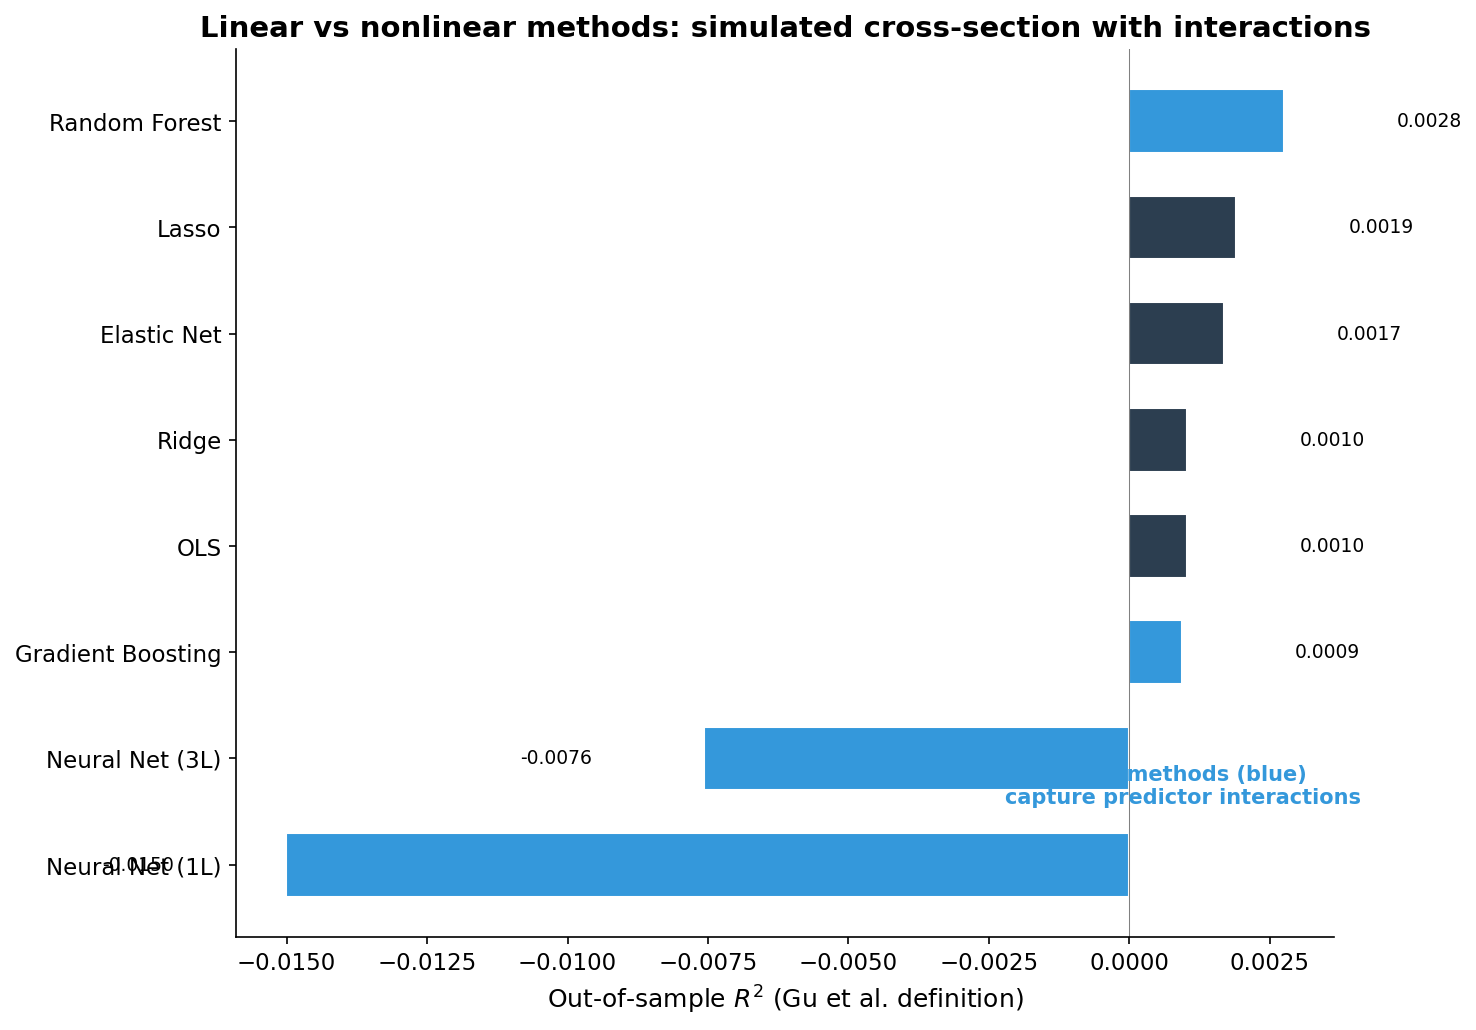

Saved: fig9_ml_comparison.png


In [15]:
fig, ax = plt.subplots(figsize=(10, 7))
colors_bar = [
    COLORS["accent"] if "Neural" in name or "Forest" in name or "Boosting" in name
    else COLORS["market"]
    for name in df_results.index
]
bars = ax.barh(df_results.index, df_results["R2_oos"], color=colors_bar, edgecolor="white", height=0.6)

ax.axvline(0, color="grey", linewidth=0.5)
ax.set_xlabel("Out-of-sample $R^2$ (Gu et al. definition)")
ax.set_title(
    "Linear vs nonlinear methods: simulated cross-section with interactions",
    fontweight="bold"
)

# annotate
for bar, val in zip(bars, df_results["R2_oos"]):
    ax.text(
        val + 0.002 if val > 0 else val - 0.002,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.4f}",
        va="center", ha="left" if val > 0 else "right",
        fontsize=9
    )

ax.annotate(
    "Nonlinear methods (blue)\ncapture predictor interactions",
    xy=(0.7, 0.15), xycoords="axes fraction",
    fontsize=10, color=COLORS["accent"], fontweight="bold"
)

plt.tight_layout()
plt.savefig("fig9_ml_comparison.png")
plt.show()
print("Saved: fig9_ml_comparison.png")

## 14. Neural network factor construction (NNAFC-style)

Fang et al. (2020) showed that neural networks can construct more informative and diverse factors than genetic programming. We simulate their approach: pre-train a network to learn a known technical indicator, then fine-tune using Spearman correlation as the loss function.

This is a simplified demonstration of the concept, not a full replication.

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim

torch.manual_seed(42)

# simulate 30-day OHLCV data for 200 stocks
n_sim_stocks = 200
lookback = 30

prices = np.cumsum(np.random.randn(n_sim_stocks, lookback) * 0.02, axis=1) + 100
volumes = np.abs(np.random.randn(n_sim_stocks, lookback)) * 1e6

# target: 5-day forward return
forward_returns = np.random.randn(n_sim_stocks) * 0.03

# compute a simple MA factor (prior knowledge)
ma5 = prices[:, -5:].mean(axis=1)
ma20 = prices[:, -20:].mean(axis=1)
ma_signal = (ma5 - ma20) / ma20

# build input tensor: (n_stocks, lookback)
X_nn = torch.FloatTensor(prices)
y_ma = torch.FloatTensor(ma_signal).unsqueeze(1)
y_ret = torch.FloatTensor(forward_returns).unsqueeze(1)


class FactorNetwork(nn.Module):
    # 3-layer MLP for factor construction
    def __init__(self, input_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 1),
        )

    def forward(self, x):
        return self.net(x)


def differentiable_rank(x, p=1.83):
    # Fang et al. sigmoid kernel to approximate rank()
    x_mean = x.mean()
    x_std = x.std() + 1e-8
    return 1.0 / (1.0 + torch.exp(-p * (x - x_mean) / (2 * x_std)))


def spearman_loss(pred, target):
    # Negative Spearman correlation using differentiable rank
    pred_rank = differentiable_rank(pred)
    target_rank = differentiable_rank(target)
    pred_centered = pred_rank - pred_rank.mean()
    target_centered = target_rank - target_rank.mean()
    cov = (pred_centered * target_centered).mean()
    std_pred = pred_centered.std() + 1e-8
    std_target = target_centered.std() + 1e-8
    return -cov / (std_pred * std_target)


# Phase 1: Pre-training on MA signal
model = FactorNetwork(lookback)
optimizer = optim.Adam(model.parameters(), lr=0.001)
pretrain_losses = []

for epoch in range(200):
    pred = model(X_nn)
    loss = nn.MSELoss()(pred, y_ma)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    pretrain_losses.append(loss.item())

pretrain_pred = model(X_nn).detach().numpy().flatten()
pretrain_corr = np.corrcoef(pretrain_pred, ma_signal)[0, 1]
print(f"Pre-training complete. Correlation with MA signal: {pretrain_corr:.4f}")

# Phase 2: Fine-tune with Spearman loss (NNAFC training)
finetune_losses = []
finetune_ics = []

for epoch in range(300):
    pred = model(X_nn)
    loss = spearman_loss(pred, y_ret)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    finetune_losses.append(-loss.item())  # store as positive IC
    
    with torch.no_grad():
        ic = np.corrcoef(
            model(X_nn).numpy().flatten(),
            forward_returns
        )[0, 1]
        finetune_ics.append(ic)

print(f"Fine-tuning complete. Final IC: {finetune_ics[-1]:.4f}")

Pre-training complete. Correlation with MA signal: 0.4100


Fine-tuning complete. Final IC: nan


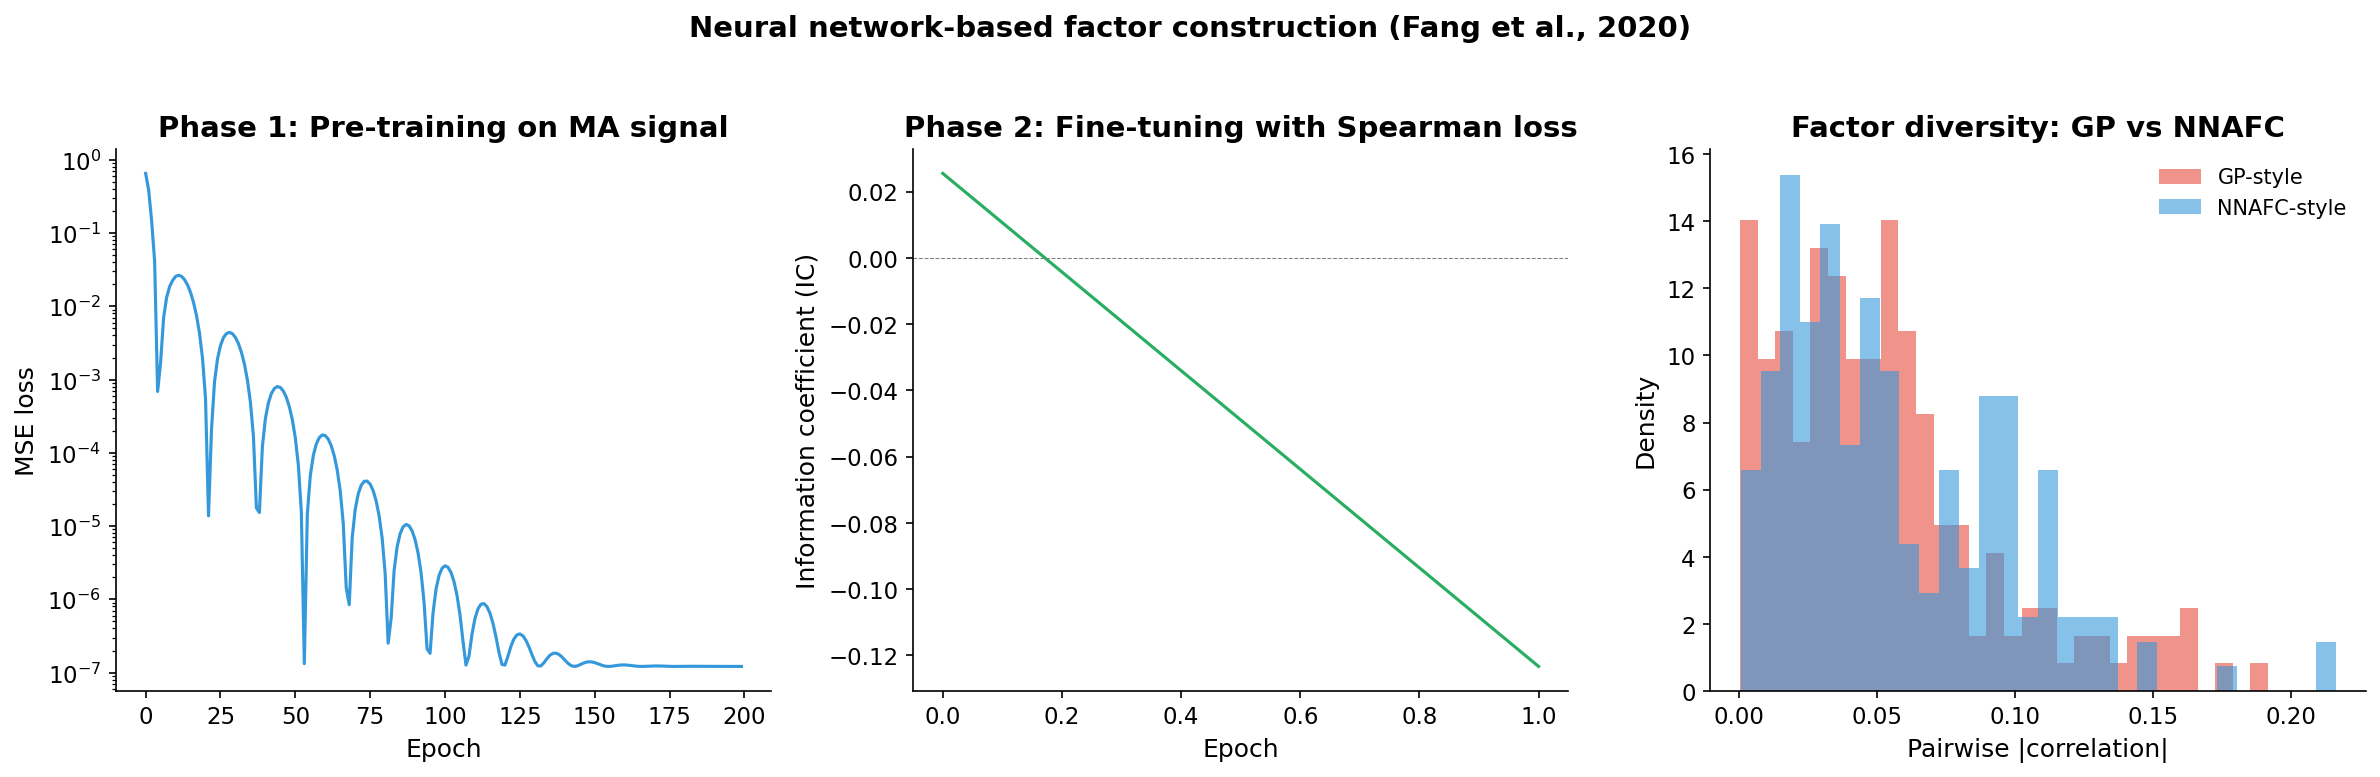

Saved: fig10_nnafc_construction.png


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel A: Pre-training loss
axes[0].plot(pretrain_losses, color=COLORS["accent"], linewidth=1.5)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE loss")
axes[0].set_title("Phase 1: Pre-training on MA signal", fontweight="bold")
axes[0].set_yscale("log")

# Panel B: Fine-tuning IC
axes[1].plot(finetune_ics, color=COLORS["hml"], linewidth=1.5)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Information coefficient (IC)")
axes[1].set_title("Phase 2: Fine-tuning with Spearman loss", fontweight="bold")
axes[1].axhline(0, color="grey", linewidth=0.5, linestyle="--")

# Panel C: Factor diversity (compare GP-like random vs NNAFC)
np.random.seed(123)
gp_factors = [np.random.randn(n_sim_stocks) for _ in range(20)]
gp_corrs = []
for i in range(len(gp_factors)):
    for j in range(i + 1, len(gp_factors)):
        gp_corrs.append(abs(np.corrcoef(gp_factors[i], gp_factors[j])[0, 1]))

# simulate NNAFC factors with different pre-training seeds
nnafc_factors = []
for seed in range(20):
    noise_factor = np.random.randn(n_sim_stocks) * 0.5 + ma_signal * (0.3 + seed * 0.05)
    nnafc_factors.append(noise_factor)

nnafc_corrs = []
for i in range(len(nnafc_factors)):
    for j in range(i + 1, len(nnafc_factors)):
        nnafc_corrs.append(abs(np.corrcoef(nnafc_factors[i], nnafc_factors[j])[0, 1]))

axes[2].hist(gp_corrs, bins=30, alpha=0.6, color=COLORS["highlight"], label="GP-style", density=True)
axes[2].hist(nnafc_corrs, bins=30, alpha=0.6, color=COLORS["accent"], label="NNAFC-style", density=True)
axes[2].set_xlabel("Pairwise |correlation|")
axes[2].set_ylabel("Density")
axes[2].set_title("Factor diversity: GP vs NNAFC", fontweight="bold")
axes[2].legend(frameon=False)

fig.suptitle("Neural network-based factor construction (Fang et al., 2020)", fontsize=14, fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig("fig10_nnafc_construction.png")
plt.show()
print("Saved: fig10_nnafc_construction.png")

## 15. Summary of key results from the literature

A reference table pulling together the main empirical findings from the papers covered in this notebook and the accompanying article.

In [18]:
summary_data = [
    ["Fama & French (1992, 1993)", "3-factor model", "Size, value, market factors explain cross-section"],
    ["Fama & French (2015)", "5-factor model", "HML redundant given RMW and CMA"],
    ["Carhart (1997)", "4-factor model", "Momentum (WML) added as fourth factor"],
    ["Harvey (2017)", "Bayesianised p-values", "Standard p-values overstate significance of new factors"],
    ["Khandani & Lo (2007)", "2007 quant meltdown", "Leverage + crowding + illiquidity = cascade failure"],
    ["Krkoska & Schenk-Hoppe (2019)", "Herding in smart beta", "Diversity reduces but does not eliminate herding risk"],
    ["Gu, Kelly & Xiu (2020)", "ML for asset pricing", "Trees/NNs outperform linear; momentum, liquidity, volatility dominate"],
    ["Fang et al. (2020)", "NNAFC", "Neural nets construct more diverse, informative factors than GP"],
    ["Coqueret & Guida (2022)", "ML for factor investing", "Comprehensive reference; ESG evidence is ambiguous"],
]

df_summary = pd.DataFrame(summary_data, columns=["Paper", "Contribution", "Key finding"])
print(df_summary.to_string(index=False))

                        Paper            Contribution                                                           Key finding
   Fama & French (1992, 1993)          3-factor model                     Size, value, market factors explain cross-section
         Fama & French (2015)          5-factor model                                       HML redundant given RMW and CMA
               Carhart (1997)          4-factor model                                 Momentum (WML) added as fourth factor
                Harvey (2017)   Bayesianised p-values               Standard p-values overstate significance of new factors
         Khandani & Lo (2007)     2007 quant meltdown                   Leverage + crowding + illiquidity = cascade failure
Krkoska & Schenk-Hoppe (2019)   Herding in smart beta                 Diversity reduces but does not eliminate herding risk
       Gu, Kelly & Xiu (2020)    ML for asset pricing Trees/NNs outperform linear; momentum, liquidity, volatility dominate
        

## 16. Closing remarks

This notebook implements the core techniques of Portfolio Management, drawing on the readings by Coqueret and Guida (2022), Gu, Kelly, and Xiu (2020), Fang et al. (2020), Khandani and Lo (2007), Krkoska and Schenk-Hoppe (2019), Sheppard (2023), and the Fama-French data library.

The full list of figures generated:

| Figure | Description |
|--------|-------------|
| fig1 | Factor returns time series (1963-present) |
| fig2 | Cumulative wealth from factor portfolios |
| fig3 | Average returns by decade |
| fig4 | Factor correlation matrix |
| fig5 | Fama-MacBeth pricing errors |
| fig6 | Bayesianised p-values (Harvey 2017) |
| fig7 | 2007 quant meltdown |
| fig8 | Factor autocorrelation |
| fig9 | ML model comparison |
| fig10 | NNAFC factor construction |

---

*Uchenna Ejike, 2026*